Supermarket Sales & Profit Analysis (Tamil Nadu)

🎯 Objective

This project analyzes supermarket grocery data from Tamil Nadu to:

*  Identify sales and profit trends
*  Understand customer and regional performance
*  Build a ML model to predict profit






In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Style
plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid")

pd.set_option('display.max_columns', None)

In [5]:
# Load data
df = pd.read_csv('super market.csv')

# Standardize column names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

# Basic info
print("Shape:", df.shape)
print("Columns:", df.columns)

df.head()

Shape: (9994, 11)
Columns: Index(['order_id', 'customer_name', 'category', 'sub_category', 'city',
       'order_date', 'region', 'sales', 'discount', 'profit', 'state'],
      dtype='object')


,order_id,customer_name,category,sub_category,city,order_date,region,sales,discount,profit,state
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


In [6]:
# Missing values
print(df.isnull().sum())

# Drop duplicates
df.drop_duplicates(inplace=True)

# Convert date
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Handle missing numeric values
df['sales'] = df['sales'].fillna(df['sales'].median())
df['profit'] = df['profit'].fillna(df['profit'].median())
df['discount'] = df['discount'].fillna(df['discount'].median())

df = df.fillna(df.mode().iloc[0])

order_id         0
customer_name    0
category         0
sub_category     0
city             0
order_date       0
region           0
sales            0
discount         0
profit           0
state            0
dtype: int64


In [7]:
# Profit Margin
df['profit_margin_pct'] = np.where(
    df['sales'] != 0,
    (df['profit'] / df['sales']) * 100,
    np.nan
)

# Loss Flag
df['loss_flag'] = np.where(df['profit'] < 0, 'Loss', 'Profit')

# Order Value
df['order_value'] = df.groupby('order_id')['sales'].transform('sum')

# Month extraction
df['month'] = df['order_date'].dt.month_name()
df['month_num'] = df['order_date'].dt.month

Exploratory Data Analysis

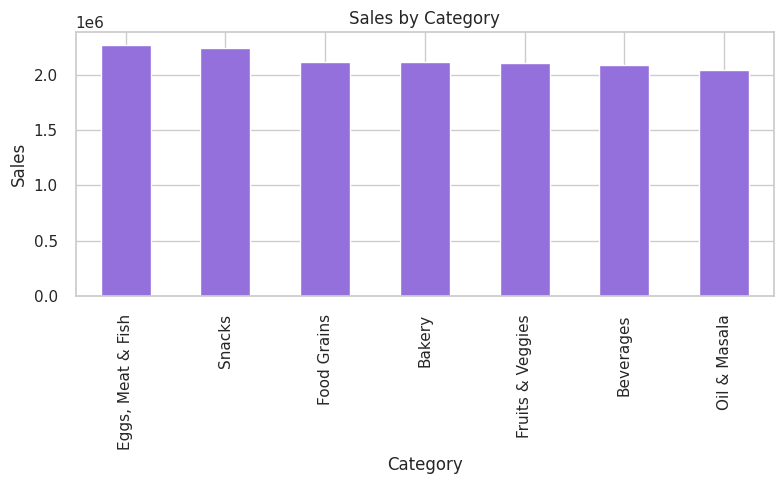

In [8]:
# Sales by Category
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color='mediumpurple')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

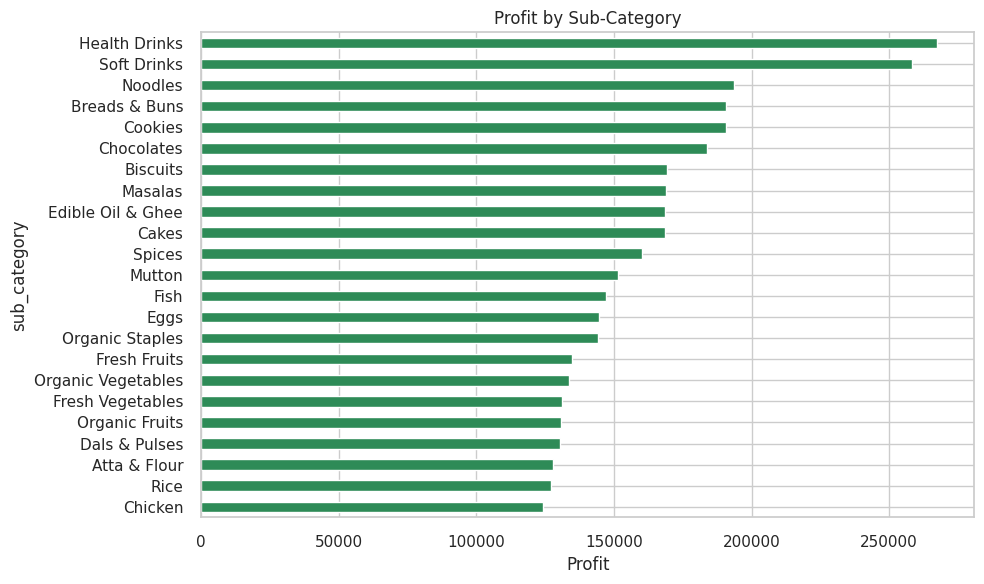

In [9]:
# Profit by Sub-Category
subcat_profit = df.groupby('sub_category')['profit'].sum().sort_values()

plt.figure(figsize=(10,6))
subcat_profit.plot(kind='barh', color='seagreen')

plt.title('Profit by Sub-Category')
plt.xlabel('Profit')

plt.tight_layout()
plt.show()

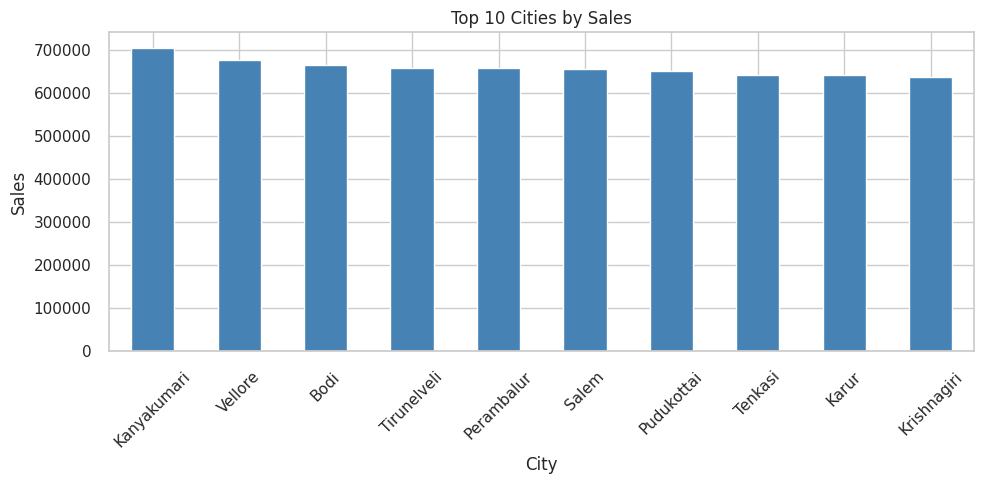

In [10]:
#Top 10 Cities by Sales
top_cities = df.groupby('city')['sales'].sum().nlargest(10)

plt.figure(figsize=(10,5))
top_cities.plot(kind='bar', color='steelblue')

plt.title('Top 10 Cities by Sales')
plt.xlabel('City')
plt.ylabel('Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

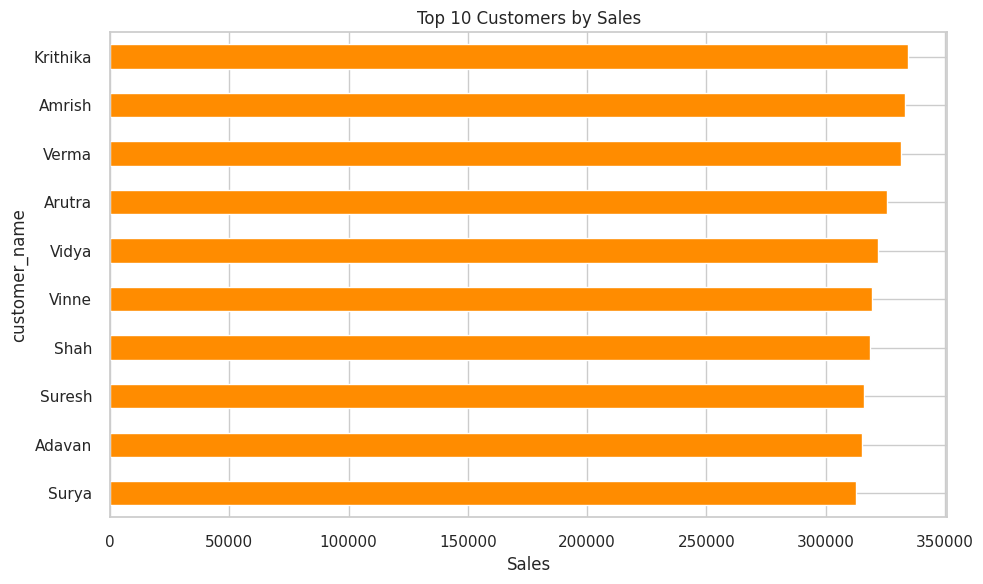

In [11]:
#Top 10 Customers
top_customers = df.groupby('customer_name')['sales'].sum().nlargest(10)

plt.figure(figsize=(10,6))
top_customers.sort_values().plot(kind='barh', color='darkorange')

plt.title('Top 10 Customers by Sales')
plt.xlabel('Sales')

plt.tight_layout()
plt.show()

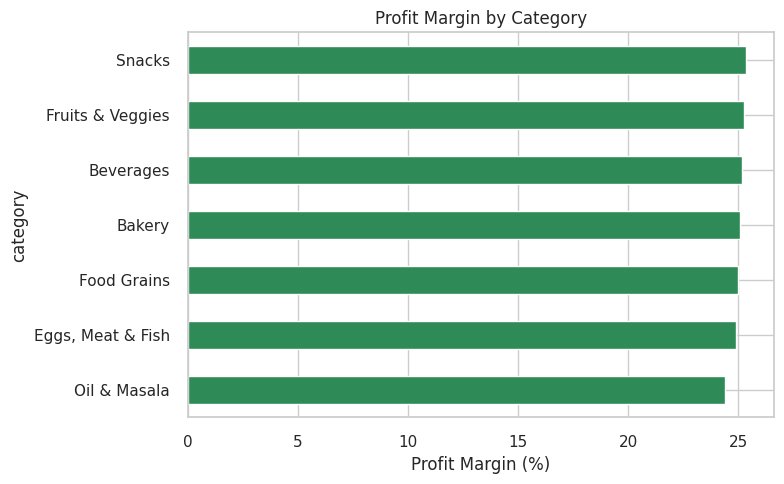

In [12]:
# Profit Margin by Category
margin_category = df.groupby('category')['profit_margin_pct'].mean().sort_values()

plt.figure(figsize=(8,5))
margin_category.plot(kind='barh', color='seagreen')

plt.title('Profit Margin by Category')
plt.xlabel('Profit Margin (%)')

plt.tight_layout()
plt.show()

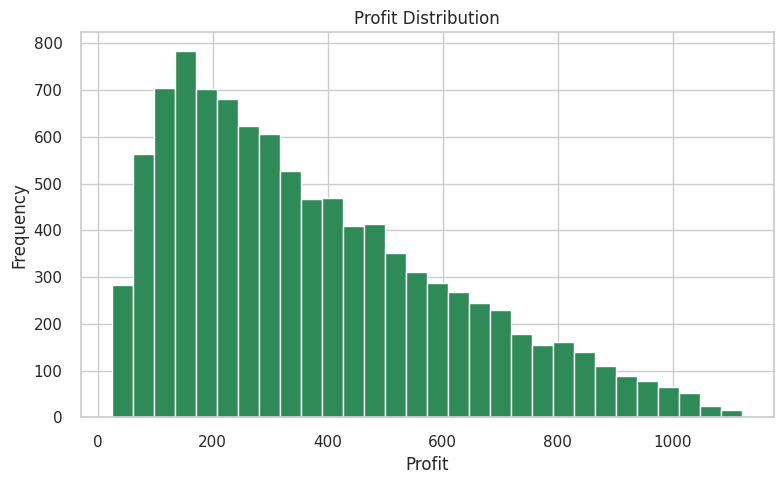

In [13]:
# Profit Distribution
plt.figure(figsize=(8,5))
plt.hist(df['profit'], bins=30, color='seagreen')

plt.title('Profit Distribution')
plt.xlabel('Profit')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

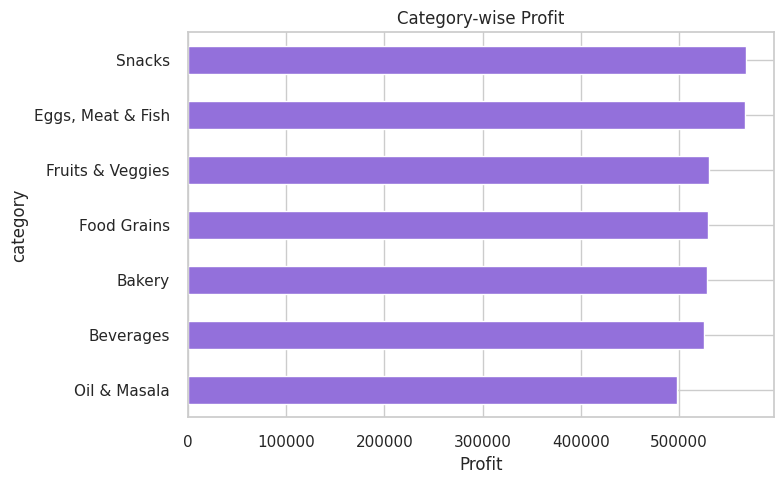

In [14]:
# Total Profit by Category
cat_profit = df.groupby('category')['profit'].sum().sort_values()

plt.figure(figsize=(8,5))
cat_profit.plot(kind='barh', color='mediumpurple')

plt.title('Category-wise Profit')
plt.xlabel('Profit')

plt.tight_layout()
plt.show()

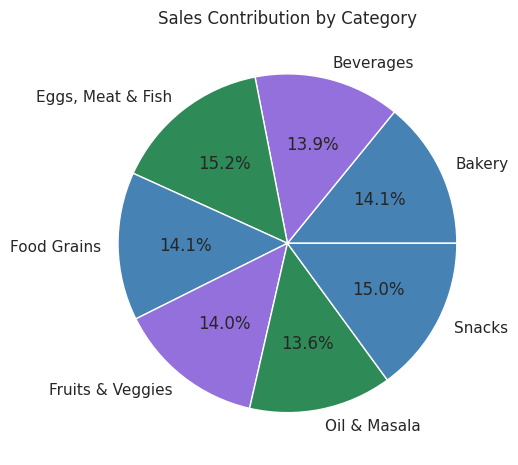

In [20]:
#Sales Contribution by Category
category_sales = df.groupby('category')['sales'].sum()

category_sales_pct = (category_sales / category_sales.sum()) * 100

category_sales_pct.plot(kind='pie', autopct='%1.1f%%', colors=['steelblue','mediumpurple','seagreen'])

plt.title('Sales Contribution by Category')
plt.ylabel('')
plt.show()

In [15]:
print("Top Category by Sales:", df.groupby('category')['sales'].sum().idxmax())
print("Most Profitable Category:", df.groupby('category')['profit'].sum().idxmax())
print("Top City:", df.groupby('city')['sales'].sum().idxmax())
print("Loss Making Sub-category:", df.groupby('sub_category')['profit'].sum().idxmin())

Top Category by Sales: Eggs, Meat & Fish
Most Profitable Category: Snacks
Top City: Kanyakumari
Loss Making Sub-category: Chicken


In [25]:
# Features & target
X = df[['sales', 'discount', 'category', 'sub_category', 'city']]
y = df['profit']

# ENCODE CATEGORICAL DATA
X = pd.get_dummies(X, drop_first=True)

# train test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(((y_test - y_pred) ** 2).mean())

print("MAE:", mae)
print("R2 Score:", r2)
print("RMSE:", rmse)


MAE: 159.366303456588
R2 Score: 0.35106866063402453
RMSE: 196.8767958566264
